# Barbados experiment

In [71]:
import pandas as pd
import numpy as np
import xarray as xr

In [18]:
data = pd.read_csv('Barbados_daily_dust.csv', encoding='latin1',sep=',')
data

,"BARBADOS DUST MASS CONCENTRATIONS: Feb 1973 - September 2015, May-September 2016, and [Jan,Feb,March,June,July,August] of 2017",Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Stn,DateOn,DateOff,Dust
1,NaN,NaN,NaN,Ash*1.3
2,NaN,NaN,NaN,(µg/m3)
3,BAR,2/18/1973,2/19/1973,0.11
4,BAR,2/19/1973,2/20/1973,0.67
...,...,...,...,...
12959,BAR,8/19/2017,8/20/2017,16.683
12960,BAR,8/20/2017,8/21/2017,59.45
12961,BAR,8/22/2017,8/23/2017,44.932
12962,BAR,8/23/2017,8/24/2017,26.237


In [20]:
data = pd.read_csv('Barbados_daily_dust.csv', encoding='latin1',sep=',', header=1)
data

,Stn,DateOn,DateOff,Dust
0,NaN,NaN,NaN,Ash*1.3
1,NaN,NaN,NaN,(µg/m3)
2,BAR,2/18/1973,2/19/1973,0.11
3,BAR,2/19/1973,2/20/1973,0.67
4,BAR,2/20/1973,2/21/1973,0.11
...,...,...,...,...
12958,BAR,8/19/2017,8/20/2017,16.683
12959,BAR,8/20/2017,8/21/2017,59.45
12960,BAR,8/22/2017,8/23/2017,44.932
12961,BAR,8/23/2017,8/24/2017,26.237


In [33]:
data = data.drop(index=[data.index[0],data.index[1]])
data

,Stn,DateOn,DateOff,Dust
2,BAR,2/18/1973,2/19/1973,0.11
3,BAR,2/19/1973,2/20/1973,0.67
4,BAR,2/20/1973,2/21/1973,0.11
5,BAR,2/21/1973,2/22/1973,0.28
6,BAR,2/22/1973,2/23/1973,0.19
...,...,...,...,...
12958,BAR,8/19/2017,8/20/2017,16.683
12959,BAR,8/20/2017,8/21/2017,59.45
12960,BAR,8/22/2017,8/23/2017,44.932
12961,BAR,8/23/2017,8/24/2017,26.237


In [55]:
data['Dust'] = data['Dust'].astype(str).str.replace(',', '').str.strip()
data['Dust'] = pd.to_numeric(data['Dust'], errors='coerce')
data

,Stn,DateOn,DateOff,Dust
2,BAR,2/18/1973,2/19/1973,0.110
3,BAR,2/19/1973,2/20/1973,0.670
4,BAR,2/20/1973,2/21/1973,0.110
5,BAR,2/21/1973,2/22/1973,0.280
6,BAR,2/22/1973,2/23/1973,0.190
...,...,...,...,...
12958,BAR,8/19/2017,8/20/2017,16.683
12959,BAR,8/20/2017,8/21/2017,59.450
12960,BAR,8/22/2017,8/23/2017,44.932
12961,BAR,8/23/2017,8/24/2017,26.237


<Axes: >

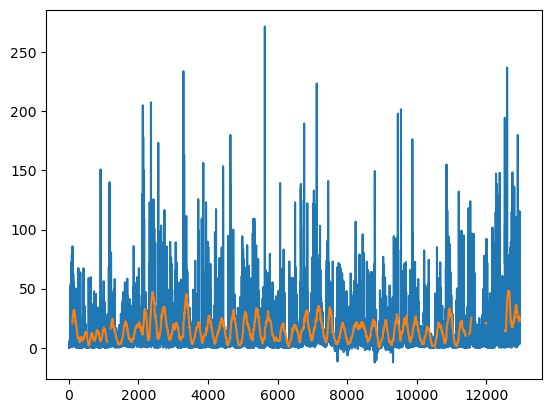

In [64]:
data.Dust.plot()
data.Dust.rolling(100).mean().plot()

<Axes: >

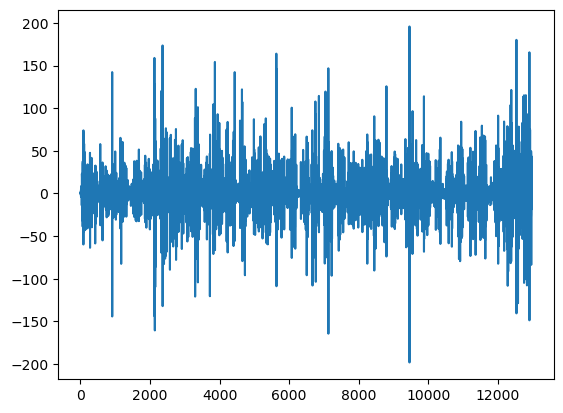

In [69]:
data.Dust.diff().plot()
# data.Dust.diff().rolling(100).mean().plot()

In [81]:
data.DateOn = data.DateOn.astype('datetime64[ns]')
data.DateOff =  data.DateOff.astype('datetime64[ns]')
data

,Stn,DateOn,DateOff,Dust
2,BAR,1973-02-18,1973-02-19,0.110
3,BAR,1973-02-19,1973-02-20,0.670
4,BAR,1973-02-20,1973-02-21,0.110
5,BAR,1973-02-21,1973-02-22,0.280
6,BAR,1973-02-22,1973-02-23,0.190
...,...,...,...,...
12958,BAR,2017-08-19,2017-08-20,16.683
12959,BAR,2017-08-20,2017-08-21,59.450
12960,BAR,2017-08-22,2017-08-23,44.932
12961,BAR,2017-08-23,2017-08-24,26.237


In [ ]:
data.D

In [73]:
da = xr.open_dataset('g4.areaAvgTimeSeries.M2TMNXAER_5_12_4_DUSMASS.20020101-20110131.59W_13N_59W_13N.nc').compute()
da

<xarray.Dataset> Size: 3kB
Dimensions:                   (time: 109, nv: 2)
Coordinates:
  * time                      (time) datetime64[ns] 872B 2002-01-01 ... 2011-...
Dimensions without coordinates: nv
Data variables:
    M2TMNXAER_5_12_4_DUSMASS  (time) float32 436B 1.322e-09 ... 9.409e-10
    datamonth                 (time) int32 436B 200201 200202 ... 201012 201101
    time_bnds                 (time, nv) datetime64[ns] 2kB 2002-01-01 ... 20...
Attributes: (12/23)
    nco_openmp_thread_number:    1
    Conventions:                 CF-1.4
    start_time:                  2002-01-01T00:00:00Z
    end_time:                    2011-01-31T23:59:59Z
    temporal_resolution:         monthly
    NCO:                         netCDF Operators version 5.0.6 (Homepage = h...
    ...                          ...
    plot_hint_y_axis_label:      kg m-3
    history:                     Sat Mar 14 13:34:52 2026: ncatted -a plot_hi...
    plot_hint_time_axis_values:  1104537600,1262304000,1420070400
    plot_hint_time_axis_labels:  2005,2010,2015
    plot_hint_time_axis_minor:   1009843200,1041379200,1072915200,1136073600,...
    plot_hint_caption:           - The user-selected region was defined by 59...

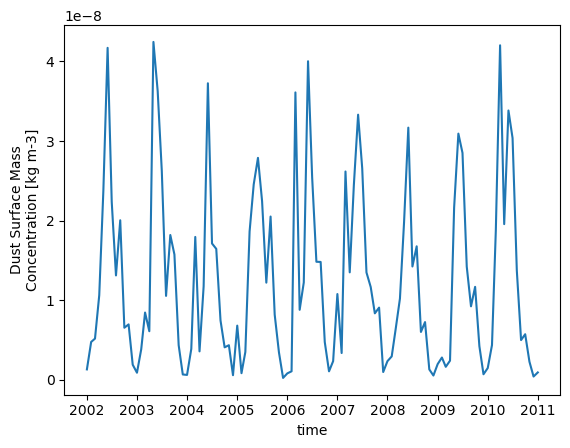

In [75]:
da.M2TMNXAER_5_12_4_DUSMASS.plot()